<a href="https://colab.research.google.com/github/IronZiiz/Machine-Learning_Classification/blob/main/Classification_diabets_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Aula 1

### Desafio 1

Faça a leitura da base de dados de diabetes e realize a divisão dos dados em variáveis explicativas e variável alvo (x e y).

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Alura/Classificação/Classificação: validação de modelos e métricas de avaliação/Desafios/diabetes.csv')

In [ ]:
data

,glicemia,pressao_sanguinea,dobra_cutane_triceps,insulina,imc,diabetes
0,66,23,94,28.1,0.167,0
1,40,35,168,43.1,2.288,1
2,50,32,88,31.0,0.248,1
3,70,45,543,30.5,0.158,1
4,60,23,846,30.1,0.398,1
...,...,...,...,...,...,...
389,88,44,510,43.3,0.222,1
390,88,39,110,36.5,1.057,1
391,58,26,16,28.4,0.766,0
392,76,48,180,32.9,0.171,0


In [ ]:
x = data.drop('diabetes', axis=1)
y = data['diabetes']

### Desafio 2

Realize a divisão dos dados entre treino e teste.

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
x, x_test, y, y_test= train_test_split(x, y, test_size=0.05, stratify = y,random_state=5)
x_train, x_validation, y_train, y_validation = train_test_split(x, y,test_size=0.25, stratify = y,random_state=5)

### Desafio 3

Crie 2 modelos utilizando os algoritmos [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) e [RandomForestClassifer](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) e avalie a acurácia de treino e teste, escolhendo valores para o parâmetro `max_depth` para os modelos não se especializarem demais no padrão dos dados de treino.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model_decision_tree = DecisionTreeClassifier(max_depth=2)
model_decision_tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [ ]:
print(f"Accuracy (train): {model_decision_tree.score(x_train, y_train)}")
print(f"Accuracy (val): {model_decision_tree.score(x_validation, y_validation)}")

Accuracy (train): 0.7357142857142858
Accuracy (val): 0.6914893617021277


In [ ]:
model_random_forest = RandomForestClassifier(max_depth=3)
model_random_forest.fit(x_train, y_train)

RandomForestClassifier(max_depth=3)

In [ ]:
print(f"Accuracy (train): {model_random_forest.score(x_train, y_train)}")
print(f"Accuracy (val): {model_random_forest.score(x_validation, y_validation)}")

Accuracy (train): 0.7857142857142857
Accuracy (val): 0.7127659574468085


### Desafio 4

Construa uma matriz de confusão para cada um dos modelos para avaliar o desempenho das previsões.

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
y_predict_decisiontree = model_decision_tree.predict(x_validation)
matrix_confusion_decisiontree = confusion_matrix(y_validation, y_predict_decisiontree)

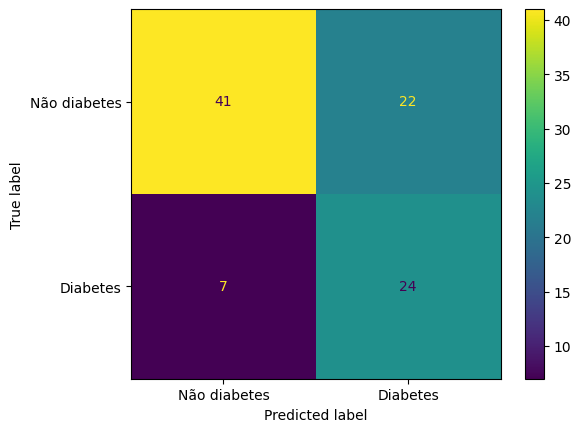

In [ ]:
viz = ConfusionMatrixDisplay(confusion_matrix=matrix_confusion_decisiontree, display_labels=['Não diabetes', 'Diabetes'])
viz.plot();

In [ ]:
y_predict_random_forest = model_random_forest.predict(x_validation)
matrix_confusion_random_forest = confusion_matrix(y_validation, y_predict_random_forest)

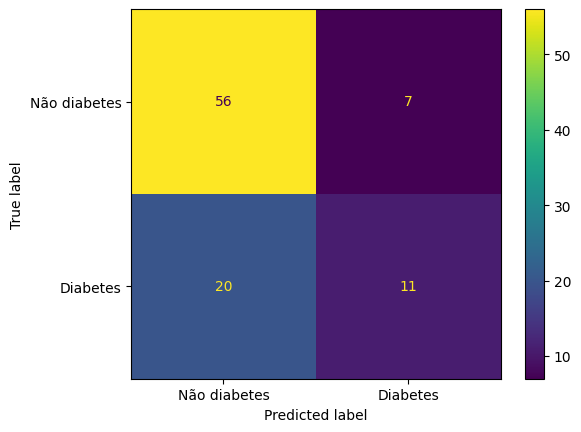

In [ ]:
viz = ConfusionMatrixDisplay(confusion_matrix=matrix_confusion_random_forest, display_labels=['Não diabetes', 'Diabetes'])
viz.plot();

# Aula 2

### Desafio 1

Extraia as métricas acurácia, recall, precisão e F1-Score dos modelos de classificação gerados no desafio da aula 1.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score

In [ ]:
print(f"Acurácia Decision Tree: {accuracy_score(y_validation, y_predict_decisiontree)}")
print(f"Acurácia Random Forest: {accuracy_score(y_validation, y_predict_random_forest)}")

Acurácia Decision Tree: 0.6914893617021277
Acurácia Random Forest: 0.7127659574468085


In [ ]:
print(f"Precisão Decision Tree: {precision_score(y_validation, y_predict_decisiontree)}")
print(f"Precisão Random Forest: {precision_score(y_validation, y_predict_random_forest)}")

Precisão Decision Tree: 0.5217391304347826
Precisão Random Forest: 0.6111111111111112


In [ ]:
print(f"Recall Decision Tree: {recall_score(y_validation, y_predict_decisiontree)}")
print(f"Recall Random Forest: {recall_score(y_validation, y_predict_random_forest)}")

Recall Decision Tree: 0.7741935483870968
Recall Random Forest: 0.3548387096774194


In [ ]:
print(f"F1-Score Decision Tree: {f1_score(y_validation, y_predict_decisiontree)}")
print(f"F1-Score Random Forest: {f1_score(y_validation, y_predict_random_forest)}")

F1-Score Decision Tree: 0.6233766233766234
F1-Score Random Forest: 0.4489795918367347


### Desafio 2

Obtenha a curva ROC e a métrica AUC dos modelos de classificação gerados no desafio da aula 1, comparando as curvas no mesmo gráfico.

*Como uma dica, vasculhe a documentação do `Scikit-learn` a partir deste [link](https://scikit-learn.org/stable/auto_examples/release_highlights/plot_release_highlights_0_22_0.html#new-plotting-api) e verifique uma forma de apresentar os resultados das curvas no mesmo gráfico usando o matplotlib*

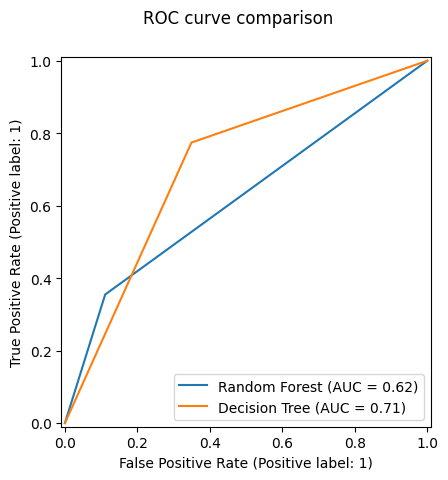

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

random_forest_roc_curve = RocCurveDisplay.from_predictions(y_validation, y_predict_random_forest , name = 'Random Forest')
decision_tree_roc_curve = RocCurveDisplay.from_predictions( y_validation, y_predict_decisiontree,name = 'Decision Tree',ax = random_forest_roc_curve.ax_)
decision_tree_roc_curve.figure_.suptitle("ROC curve comparison")
plt.show()

### Desafio 3

Obtenha a curva precisão x recall e a métrica AP dos modelos de classificação gerados no desafio da aula 1, comparando as curvas no mesmo gráfico.

*Como uma dica, vasculhe a documentação do `Scikit-learn` a partir deste [link](https://scikit-learn.org/stable/auto_examples/release_highlights/plot_release_highlights_0_22_0.html#new-plotting-api) e verifique uma forma de apresentar os resultados das curvas no mesmo gráfico usando o matplotlib*

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

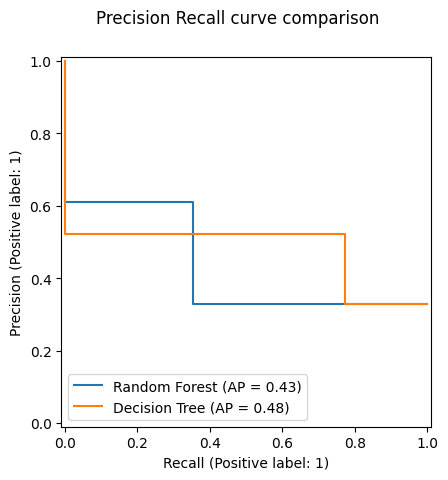

In [ ]:
random_forest_roc_curve = PrecisionRecallDisplay.from_predictions(y_validation, y_predict_random_forest, name = 'Random Forest')
decision_tree_roc_curve = PrecisionRecallDisplay.from_predictions( y_validation, y_predict_decisiontree,name = 'Decision Tree', ax = random_forest_roc_curve.ax_)
decision_tree_roc_curve.figure_.suptitle("Precision Recall curve comparison")
plt.show()

### Desafio 4

Gere os relatórios de métricas dos modelos de classificação gerados no desafio da aula 1.

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_validation, y_predict_decisiontree))

              precision    recall  f1-score   support

           0       0.85      0.65      0.74        63
           1       0.52      0.77      0.62        31

    accuracy                           0.69        94
   macro avg       0.69      0.71      0.68        94
weighted avg       0.74      0.69      0.70        94



In [ ]:
print(classification_report(y_validation, y_predict_random_forest))

              precision    recall  f1-score   support

           0       0.74      0.89      0.81        63
           1       0.61      0.35      0.45        31

    accuracy                           0.71        94
   macro avg       0.67      0.62      0.63        94
weighted avg       0.70      0.71      0.69        94



# Aula 3

### Desafio 1

Crie uma função para calcular o intervalo de confiança dos resultados de uma validação cruzada com 2 desvios padrão. A função precisa ter um parâmetro para receber uma lista com os desempenhos da validação cruzada e outro para apresentar o nome do modelo utilizado na validação cruzada. Exemplo de retorno da função:

> Intervalo de confiança ("nome do modelo"): ["valor mínimo do intervalo", "valor máximo do intervalo"]



In [ ]:
def confidence_interval(scores, model_name):
  mean = scores.mean()
  std = scores.std()
  print(f'{model_name} :Confidence Interval: {mean - 2 * std} , {min(mean + 2 *std,1)}')

### Desafio 2

Avalie o desempenho dos modelos com um intervalo de confiança utilizando a validação cruzada com o método [`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html), usando 10 partes e embaralhando os dados antes da separação. Use o método [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) que não retorna o tempo de execução, apenas as métricas.

In [ ]:
from sklearn.model_selection import cross_validate, KFold, cross_val_score

In [ ]:
kf = KFold(n_splits = 10, shuffle = True, random_state = 5)
cv_results_accuracy = cross_val_score(model_decision_tree, x, y, cv=kf, scoring='accuracy')


In [ ]:
confidence_interval(cv_results_accuracy,'Decision Tree')

Decision Tree :Confidence Interval: 0.5294365926800135 , 0.8402646875475823


### Desafio 3

Avalie o desempenho dos modelos com um intervalo de confiança utilizando a validação cruzada (`cross_val_score`) com o método [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html#sklearn.model_selection.StratifiedKFold), usando 10 partes e embaralhando os dados antes da separação e avaliando a métrica F1-Score.

In [ ]:
from sklearn.model_selection import StratifiedKFold


In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_stratified_kfold_decision_tree = cross_val_score(model_decision_tree, x, y, cv = skf, scoring = 'f1')
cv_results_stratified_kfold_random_forest = cross_val_score(model_random_forest, x, y, cv = skf, scoring = 'f1')

In [ ]:
confidence_interval(cv_results_stratified_kfold_decision_tree,'Decision Tree')
confidence_interval(cv_results_stratified_kfold_random_forest,'Random Forest')

Decision Tree :Confidence Interval: 0.5284687221860518 , 0.666434929516148
Random Forest :Confidence Interval: 0.2393840675702971 , 0.6349602177999658


### Desafio 4

Avalie o desempenho dos modelos utilizando a validação cruzada (`cross_val_score`) com o método [`LeaveOneOut`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html).

O método LeaveOneOut vai gerar um modelo para cada uma das linhas da base de dados, portanto a lista de resultados terá taxa de acerto apenas de 0 ou 1 para cada modelo. Dessa forma, extraia apenas a média do resultado, sem utilizar o intervalo de confiança.


In [ ]:
from sklearn.model_selection import LeaveOneOut, cross_val_score


In [ ]:
loo = LeaveOneOut()
cv_results_loo = cross_val_score(model_decision_tree, x, y, cv=loo, scoring='accuracy')


In [ ]:
cv_results_loo.mean()

np.float64(0.6844919786096256)

# Aula 4

### Desafio 1

Verifique a proporção de dados da variável alvo do conjunto de dados de diabetes. Essa análise pode ser feita a partir da porcentagem de dados ou com a utilização de um gráfico de contagem para entender se há um desbalanceamento de dados.

In [ ]:
y.value_counts()

,count
diabetes,
0,251
1,123


In [ ]:
print(y.value_counts(normalize=True) * 100)

diabetes
0    67.112299
1    32.887701
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt


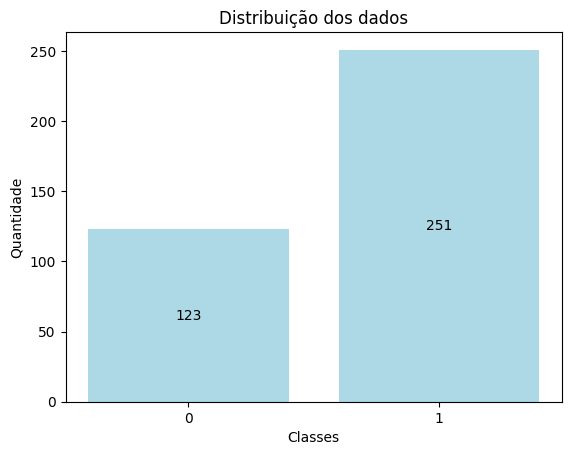

In [ ]:
fig = plt.bar(y.unique(), y.value_counts(), color = 'lightblue')
plt.xticks(y.unique())
plt.title('Distribuição dos dados')
plt.xlabel('Classes')
plt.ylabel('Quantidade')

plt.bar_label(fig, fmt='%d', label_type='center')
plt.show()

### Desafio 2

Utilize um [`pipeline`](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html) contendo ajuste do modelo e o balanceamento dos dados usando o oversampling com [`SMOTE`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html), obtendo a média do F1-Score de uma validação cruzada com `StratifiedKFold`.

In [ ]:
from imblearn.pipeline import Pipeline as imbpip
from imblearn.over_sampling import SMOTE

In [ ]:
pipeline_smte = imbpip(steps = [['smote', SMOTE(random_state=5)], ['model', model_decision_tree]])


In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_pipeline= cross_val_score(pipeline_smte, x, y, cv = skf, scoring = 'f1')

In [ ]:
confidence_interval(cv_results_pipeline, 'Decision Tree Model')

Decision Tree Model :Confidence Interval: 0.5436207598705449 , 0.6436019339608077


### Desafio 3

 Utilize um [`pipeline`](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html) contendo ajuste do modelo e o balanceamento dos dados usando o undersampling com [`Nearmiss`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) na sua versão 3, obtendo a média do F1-Score de uma validação cruzada com `StratifiedKFold`.

In [ ]:
from imblearn.under_sampling import NearMiss

In [ ]:
pipeline_near_miss = imbpip(steps = [('undersample', NearMiss(version = 3)), ('tree', model_decision_tree)])

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_results_pipeline= cross_val_score(pipeline_near_miss, x, y, cv = skf, scoring = 'f1')

In [ ]:
confidence_interval(cv_results_pipeline, 'Decision Tree Model')

Decision Tree Model :Confidence Interval: 0.2378574395289662 , 0.7475819621368507


### Desafio 4

Escolha o modelo que obteve o melhor desempenho ao comparar as estratégias de oversampling e undersampling e realize o teste do modelo nos dados de teste que foram separados no início dos desafios.

In [ ]:
undersample = SMOTE(random_state=5)
x_train_resampled, y_train_resampled = undersample.fit_resample(x, y)

In [ ]:
model_final = DecisionTreeClassifier(max_depth=10)
model_final.fit(x_train_resampled, y_train_resampled)

DecisionTreeClassifier(max_depth=10)

In [ ]:
y_predict = model_final.predict(x_test)

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.67      0.62      0.64        13
           1       0.38      0.43      0.40         7

    accuracy                           0.55        20
   macro avg       0.52      0.52      0.52        20
weighted avg       0.56      0.55      0.56        20



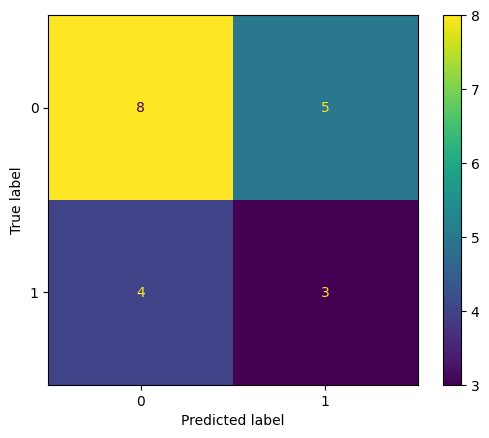

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predict)
plt.show()